In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("/kaggle/input/datasets/bhanageviraj/india-atm-card-and-digital-payments-statistics/RBI_ATM_Card_Statistics_Apr2025_Jan2026.csv")

In [3]:
# Dataset info
print(df.shape)
print(df.head())
print(df.columns.tolist())
print(df.info())

(640, 28)
               Bank_Name  ATMs_On_Site  ATMs_Off_Site      PoS  Micro_ATMs  \
0         BANK OF BARODA        9065.0         2498.0  54921.0     42154.0   
1          BANK OF INDIA        5201.0         2494.0  19012.0     25206.0   
2    BANK OF MAHARASHTRA        2366.0          250.0    271.0      6273.0   
3            CANARA BANK        7444.0         3343.0  91899.0     12000.0   
4  CENTRAL BANK OF INDIA        2953.0         1223.0   3461.0      2816.0   

   Bharat_QR_Codes  UPI_QR_Codes  Credit_Cards_Outstanding  \
0          26609.0     3111464.0                 3067672.0   
1              0.0     1401822.0                   97552.0   
2         355014.0      958837.0                       0.0   
3              0.0     3798016.0                 1070400.0   
4          38138.0     1923040.0                       0.0   

   Debit_Cards_Outstanding  CC_Vol_PoS  ...    DC_Val_PoS  DC_Vol_Online  \
0               88543345.0   9344751.0  ...  6.458732e+06       346759.0

In [4]:
print("Shape:", df.shape)
print("\nMissing Values:", df.isnull().sum().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nUnique Banks:", df['Bank_Name'].nunique())
print("\nUnique Months:", df['Reporting_Month'].nunique())
print("\nMonths:", df['Reporting_Month'].unique())

Shape: (640, 28)

Missing Values: 0

Duplicates: 1

Unique Banks: 65

Unique Months: 9

Months: ['December' 'April' 'August' 'January' 'July' 'June' 'May' 'October'
 'September']


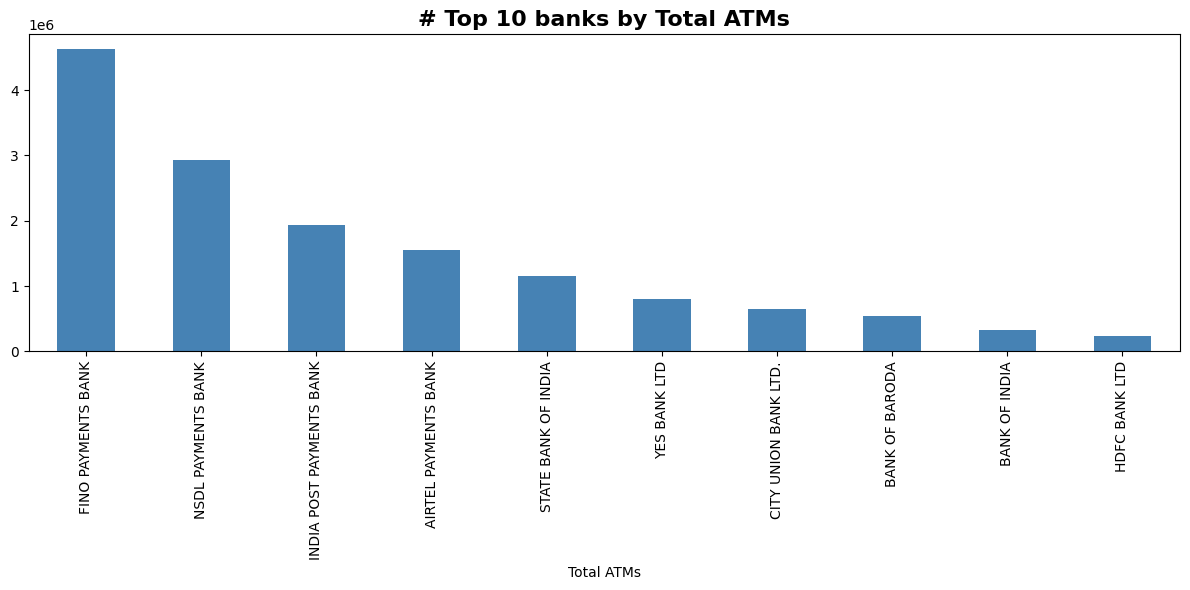

In [6]:
# Top 10 banks by ATM's
df['Total_ATMs'] = df['ATMs_On_Site'] + df['ATMs_Off_Site'] + df['Micro_ATMs']

top_atm_banks = df.groupby('Bank_Name')['Total_ATMs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_atm_banks.plot(kind='bar', color='steelblue')
plt.title('# Top 10 banks by Total ATMs', fontsize=16, fontweight='bold')
plt.xlabel('Total ATMs')
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

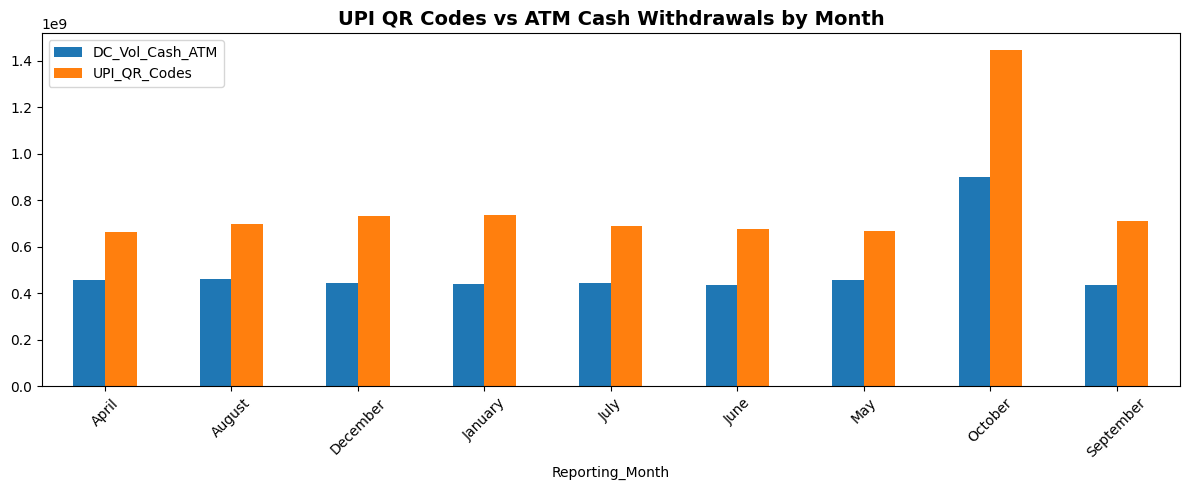

In [7]:
# UPI vs ATM cash withdrawals 
monthly = df.groupby('Reporting_Month')[['DC_Vol_Cash_ATM', 'UPI_QR_Codes']].sum()

plt.figure(figsize=(12, 5))
monthly.plot(kind='bar', figsize=(12, 5))
plt.title('UPI QR Codes vs ATM Cash Withdrawals by Month', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

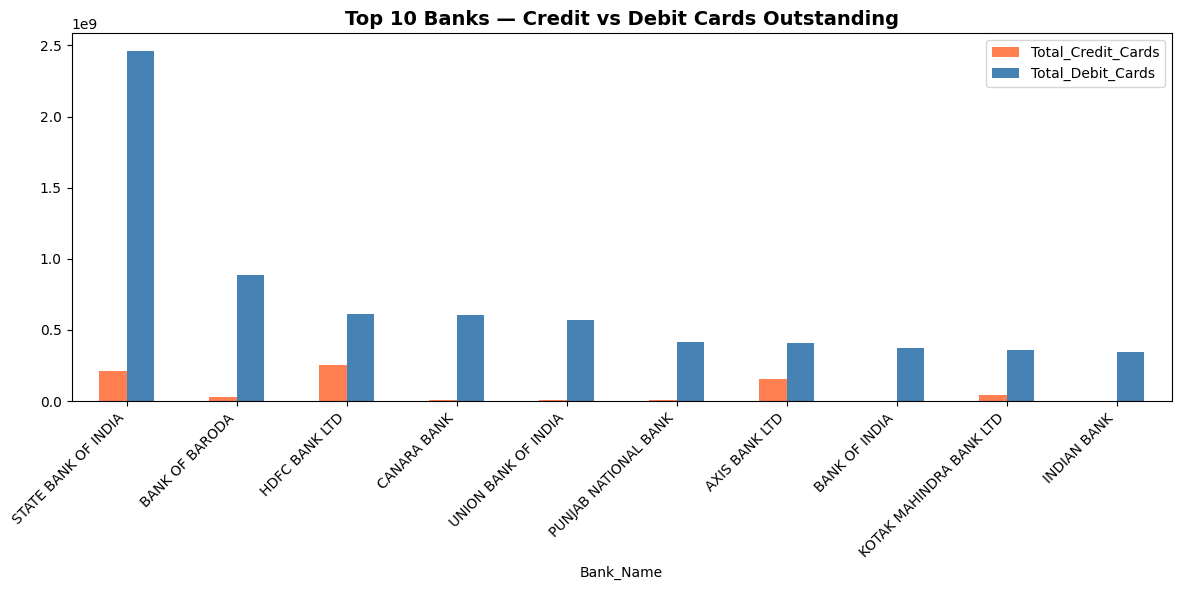

In [8]:
# Credit Card vs Debit Cards Outstanding
df['Total_Credit_Cards'] = df['Credit_Cards_Outstanding']
df['Total_Debit_Cards'] = df['Debit_Cards_Outstanding']

card_by_bank = df.groupby('Bank_Name')[['Total_Credit_Cards', 'Total_Debit_Cards']].sum()
top_cards = card_by_bank.sort_values('Total_Debit_Cards', ascending=False).head(10)

top_cards.plot(kind='bar', figsize=(12, 6), color=['coral', 'steelblue'])
plt.title('Top 10 Banks — Credit vs Debit Cards Outstanding', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

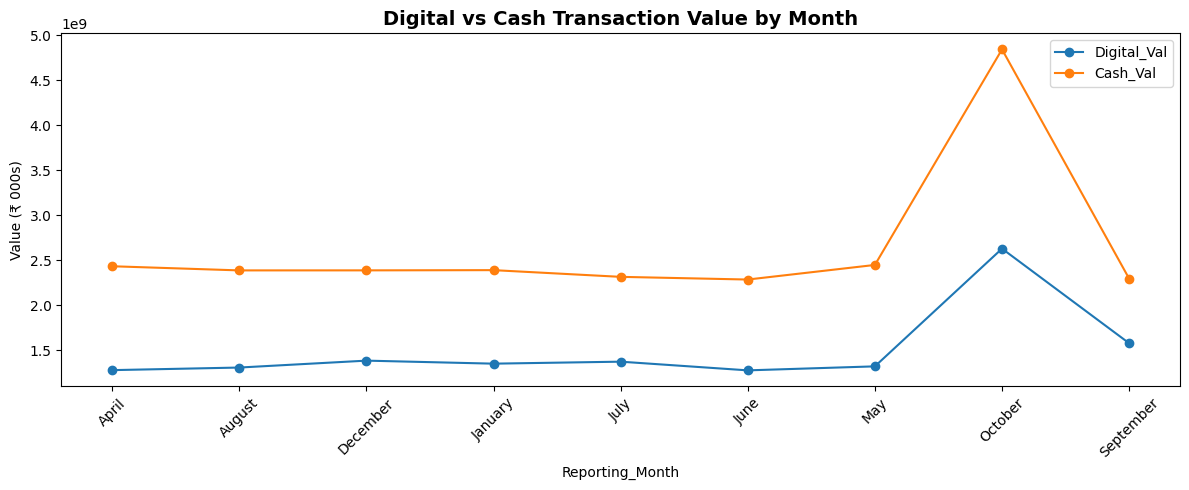

In [9]:
# Digital vs Cash Transaction value
df['Digital_Val'] = df['CC_Val_Online'] + df['DC_Val_Online']
df['Cash_Val'] = df['DC_Val_Cash_ATM']

digital_vs_cash = df.groupby('Reporting_Month')[['Digital_Val', 'Cash_Val']].sum()

digital_vs_cash.plot(kind='line', figsize=(12, 5), marker='o')
plt.title('Digital vs Cash Transaction Value by Month', fontsize=14, fontweight='bold')
plt.ylabel('Value (₹ 000s)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

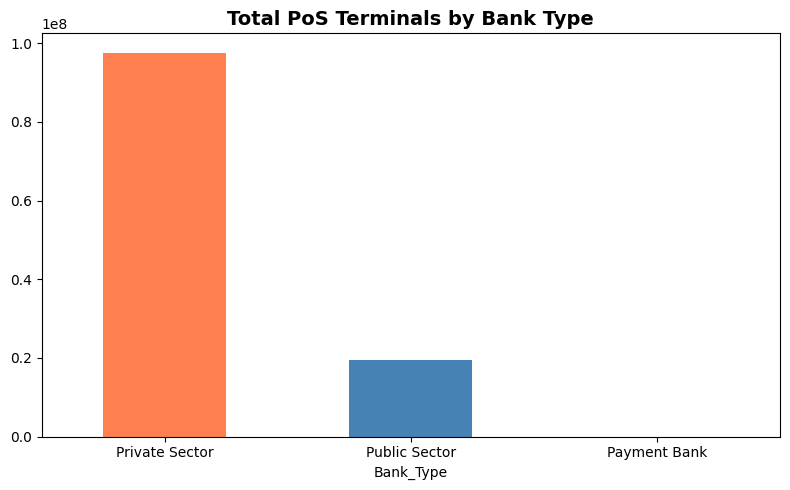

In [10]:
# PoS terminals by Bank type
# Classify bank type
def classify_bank(name):
    if any(x in name for x in ['PAYMENTS BANK', 'FINO', 'AIRTEL', 'NSDL', 'INDIA POST']):
        return 'Payment Bank'
    elif any(x in name for x in ['SBI', 'BANK OF INDIA', 'CANARA', 'PUNJAB NATIONAL',
                                   'BANK OF BARODA', 'UNION BANK', 'CENTRAL BANK',
                                   'BANK OF MAHARASHTRA', 'UCO', 'INDIAN BANK']):
        return 'Public Sector'
    else:
        return 'Private Sector'

df['Bank_Type'] = df['Bank_Name'].apply(classify_bank)

bank_type_pos = df.groupby('Bank_Type')['PoS'].sum().sort_values(ascending=False)

bank_type_pos.plot(kind='bar', figsize=(8, 5), color=['coral', 'steelblue', 'green'])
plt.title('Total PoS Terminals by Bank Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 📊 Key Insights

### 1. Payment Banks Dominate Micro ATM Infrastructure
FINO, NSDL, and India Post lead in total ATMs — not SBI or HDFC.
This is because Payment Banks deploy Micro ATMs aggressively
for last-mile rural banking access.

### 2. Cash Still King, But October Tells a Story
Despite UPI growth, ATM cash withdrawals remain consistently higher
in VALUE. However, October shows a massive spike in BOTH digital
and cash — driven by Diwali festival spending.

### 3. Private Banks Own the PoS Economy
Private sector banks operate ~5x more PoS terminals than
public sector banks — indicating stronger merchant partnerships
and urban retail focus.

### 4. SBI's Debit Card Monopoly
SBI has 2.5 BILLION debit cards outstanding — more than all
other top 9 banks combined. Yet HDFC leads in credit cards,
reflecting the urban premium customer base.

### 5. India's Digital Transition is Real but Gradual
UPI QR codes outnumber ATM withdrawals in VOLUME every month,
but cash still leads in VALUE — meaning UPI handles many
small transactions while large payments remain cash-dominant.
